# Student Performance Data Analysis

Exploratory data analysis using Python (Pandas, NumPy, Matplotlib, Seaborn, scikit-learn).

**Goals:**
- Explore correlations between study habits and grades
- Visualize dataset patterns
- Build and compare simple predictive models

## Dataset
We use the **Student Performance** dataset from the **UCI Machine Learning Repository** (ID 320).  
649 Portuguese secondary school students, 33 variables, target: **G3** (final grade, 0–20).


In [7]:
# Uncomment the next line the first time you run the notebook
!pip install ucimlrepo pandas numpy matplotlib seaborn scikit-learn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression

sns.set_theme(style="whitegrid")


     ---------------------------------------- 0.0/61.0 kB ? eta -:--:--
     ---------------------------------------- 61.0/61.0 kB 1.1 MB/s eta 0:00:00
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.9 MB 8.6 MB/s eta 0:00:02
   ---- ----------------------------------- 1.1/9.9 MB 18.0 MB/s eta 0:00:01
   -------- ------------------------------- 2.0/9.9 MB 15.9 MB/s eta 0:00:01
   ----------- ---------------------------- 2.9/9.9 MB 16.8 MB/s eta 0:00:01
   ----------------- ---------------------- 4.2/9.9 MB 20.8 MB/s eta 0:00:01
   --------------------- ------------------ 5.2/9.9 MB 20.8 MB/s eta 0:00:01
   ------------------------ --------------- 6.1/9.9 MB 20.4 MB/s eta 0:00:01
   ----------------------------- ---------- 7.2/9.9 MB 22.0 MB/s eta 0:00:01
   --------------------------------- ------ 8.3/9.9 MB 22.1 MB/s eta 0:00:01
   ---------------------------------------  9.8/9.9 MB 22.3 MB/s eta 0:00:01
   -------


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\benit\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


## 1. Load the dataset

In [8]:
student_performance = fetch_ucirepo(id=320)

X = student_performance.data.features.copy()
y = student_performance.data.targets.copy()

df = pd.concat([X, y], axis=1)

print("Shape:", df.shape)
display(df.head())


Shape: (649, 33)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


## 2. Quick overview

In [9]:
print("Column types:")
display(df.dtypes)

print("\nMissing values per column (all columns):")
missing = df.isna().sum().sort_values(ascending=False)
display(missing)
print(f"→ Total missing values: {missing.sum()} — dataset is complete.")

print("\nNumeric summary:")
display(df.describe())


Column types:


school          str
sex             str
age           int64
address         str
famsize         str
Pstatus         str
Medu          int64
Fedu          int64
Mjob            str
Fjob            str
reason          str
guardian        str
traveltime    int64
studytime     int64
failures      int64
schoolsup       str
famsup          str
paid            str
activities      str
nursery         str
higher          str
internet        str
romantic        str
famrel        int64
freetime      int64
goout         int64
Dalc          int64
Walc          int64
health        int64
absences      int64
G1            int64
G2            int64
G3            int64
dtype: object


Missing values per column (all columns):


school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

→ Total missing values: 0 — dataset is complete.

Numeric summary:


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000
mean,16.744222,2.514638,2.306626,1.568567,1.930663,0.221880,3.930663,3.180277,3.184900,1.502311,2.280431,3.536210,3.659476,11.399076,11.570108,11.906009
std,1.218138,1.134552,1.099931,0.748660,0.829510,0.593235,0.955717,1.051093,1.175766,0.924834,1.284380,1.446259,4.640759,2.745265,2.913639,3.230656
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,16.000000,2.000000,1.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,2.000000,0.000000,10.000000,10.000000,10.000000
50%,17.000000,2.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,2.000000,11.000000,11.000000,12.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,6.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,32.000000,19.000000,19.000000,19.000000


### Observations

- The dataset has **649 students and 33 variables**: 16 numeric, 17 categorical (binary yes/no or multi-class).
- **No missing values** in any column — no imputation is strictly necessary for this dataset, though the model pipeline includes it for robustness.
- The target variable **G3** has a mean of ~11.9 (out of 20) and a standard deviation of ~3.2, with scores ranging from 0 to 19.  
  The distribution is roughly bell-shaped with a notable mass of students scoring 0 (likely dropouts or absences from the final exam).


## 3. Focus on useful variables

The final grade is **G3**.  
For a first analysis, we focus on variables that are plausibly linked to academic outcomes:

| Variable | Type | Description |
|----------|------|-------------|
| `studytime` | ordinal (1–4) | Weekly study time |
| `failures` | int | Number of past class failures |
| `absences` | int | Number of school absences |
| `internet` | binary | Internet access at home |
| `higher` | binary | Wants to pursue higher education |
| `G1`, `G2` | int | First and second period grades |
| `G3` | int | **Target** — final period grade |


In [10]:
selected_cols = ["studytime", "failures", "absences", "internet", "higher", "G1", "G2", "G3"]
display(df[selected_cols].describe())


,studytime,failures,absences,G1,G2,G3
count,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000
mean,1.930663,0.221880,3.659476,11.399076,11.570108,11.906009
std,0.829510,0.593235,4.640759,2.745265,2.913639,3.230656
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,0.000000,10.000000,10.000000,10.000000
50%,2.000000,0.000000,2.000000,11.000000,11.000000,12.000000
75%,2.000000,0.000000,6.000000,13.000000,13.000000,14.000000
max,4.000000,3.000000,32.000000,19.000000,19.000000,19.000000


## 4. Correlation analysis

Pearson correlations with G3:


G3            1.000000
G2            0.918548
G1            0.826387
studytime     0.249789
Medu          0.240151
Fedu          0.211800
famrel        0.063361
goout        -0.087641
absences     -0.091379
health       -0.098851
age          -0.106505
freetime     -0.122705
traveltime   -0.127173
Walc         -0.176619
Dalc         -0.204719
failures     -0.393316
Name: G3, dtype: float64

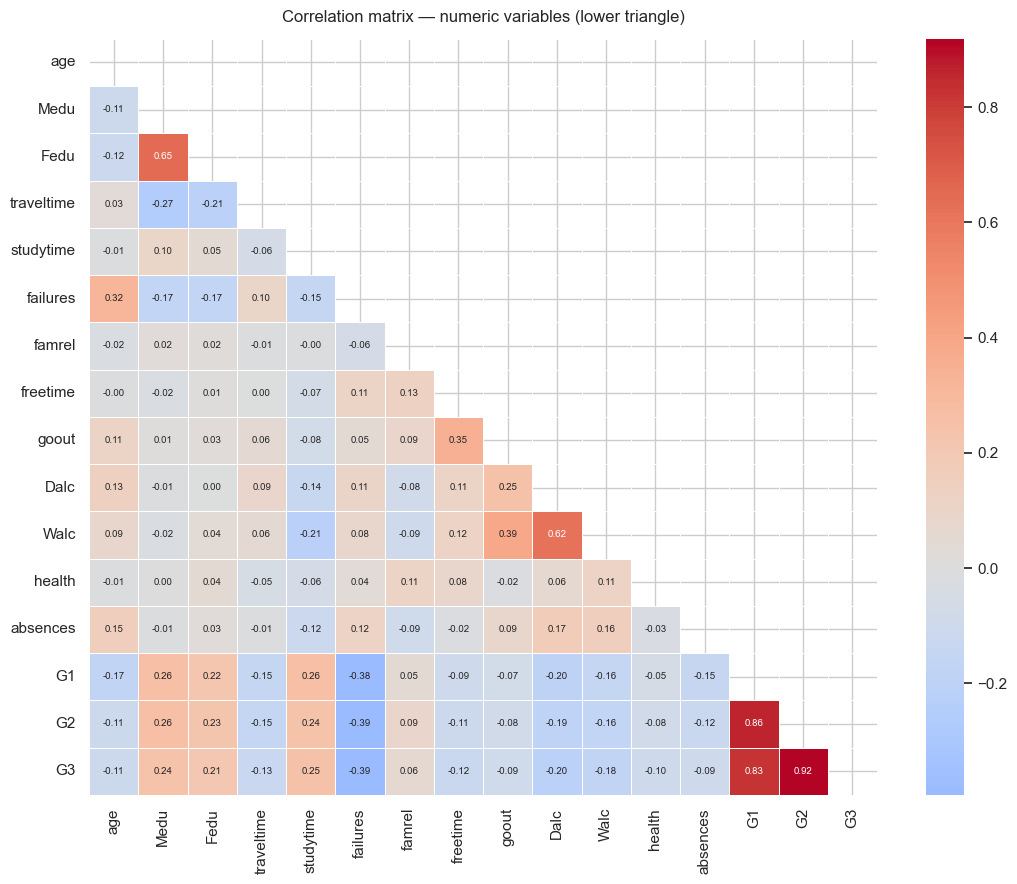

In [11]:
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr(numeric_only=True)

corr_target = corr["G3"].sort_values(ascending=False)
print("Pearson correlations with G3:")
display(corr_target)

# Annotated heatmap using seaborn
plt.figure(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))  # show only lower triangle
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    annot_kws={"size": 7},
)
plt.title("Correlation matrix — numeric variables (lower triangle)", pad=12)
plt.tight_layout()
plt.show()


### Observations

**Strongest positive correlations with G3:**
- `G2`: **+0.92** and `G1`: **+0.83** — prior period grades are by far the best predictors of the final grade.  
  This is expected: academic performance is highly autocorrelated within a course.
- `Medu` (+0.22) and `Fedu` (+0.21): parental education level shows a modest positive association.
- `studytime`: **+0.25** — a weak but consistent positive tendency.

**Strongest negative correlations with G3:**
- `failures`: **−0.39** — the most informative non-grade predictor.  
  Students with more past failures score significantly lower on average.
- `Dalc` (daily alcohol): **−0.21**, `Walc` (weekend alcohol): **−0.18**.

**Notable multicollinearity:** G1 and G2 are very strongly correlated with each other (r ≈ 0.85),  
which is expected since they measure performance in the same course.


## 5. Visualizations

C:\Users\benit\AppData\Local\Temp\ipykernel_41916\1716921792.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="studytime", y="G3", ax=axes[0, 1], palette="Blues")
C:\Users\benit\AppData\Local\Temp\ipykernel_41916\1716921792.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="internet", y="G3", ax=axes[1, 1], palette="Set2")
C:\Users\benit\AppData\Local\Temp\ipykernel_41916\1716921792.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="higher", y="G3", ax=axes[1, 2], palette="Set1")


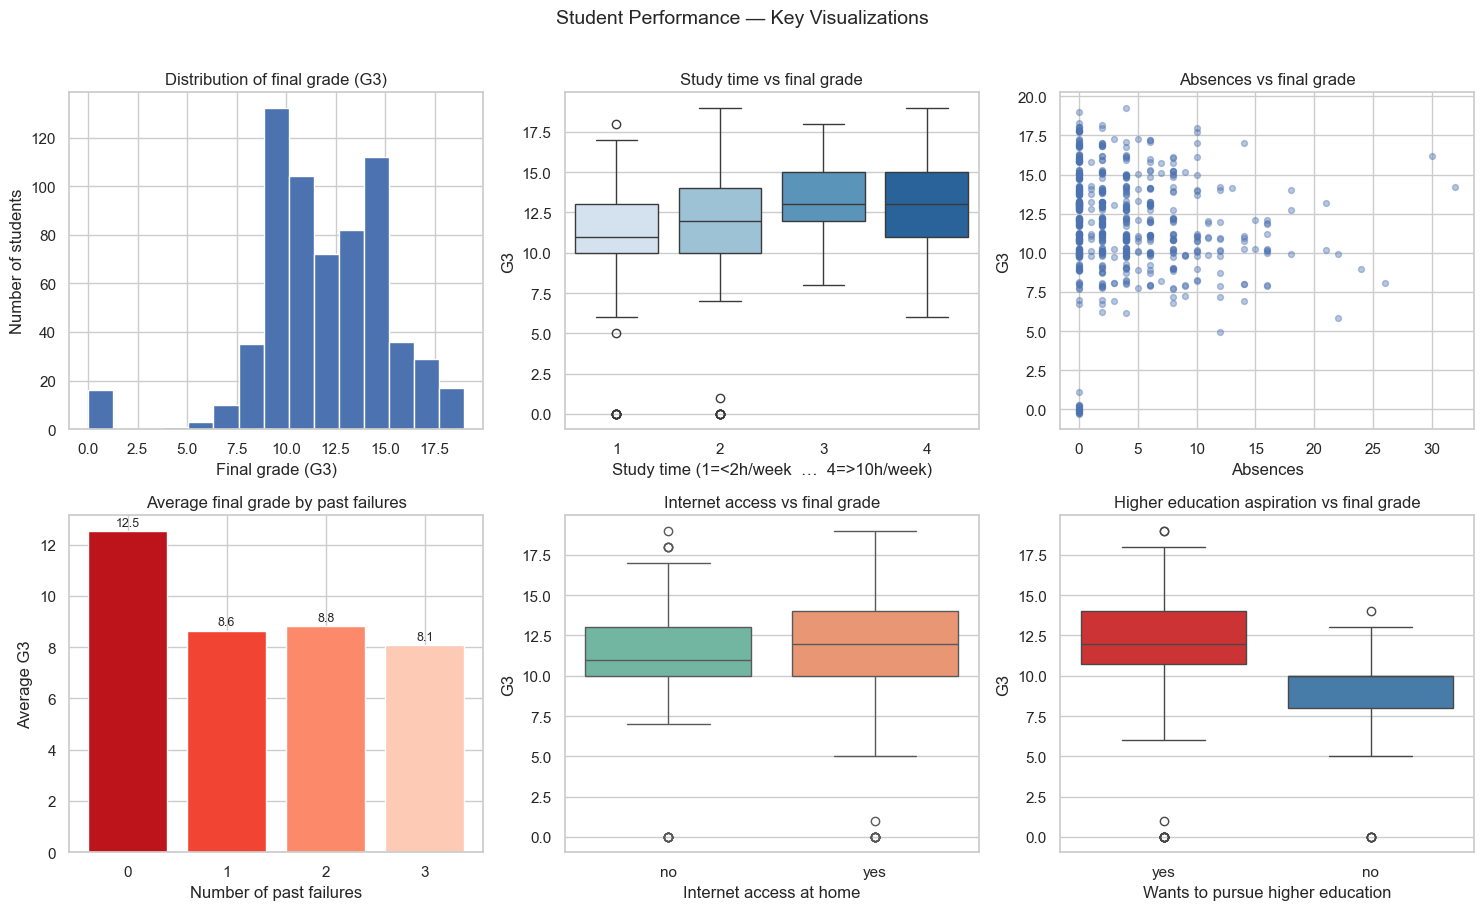

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle("Student Performance — Key Visualizations", fontsize=14, y=1.01)

# 1. G3 distribution
axes[0, 0].hist(df["G3"], bins=15, color=sns.color_palette()[0], edgecolor="white")
axes[0, 0].set_title("Distribution of final grade (G3)")
axes[0, 0].set_xlabel("Final grade (G3)")
axes[0, 0].set_ylabel("Number of students")

# 2. studytime vs G3 — boxplot (better than scatter for ordinal variable)
sns.boxplot(data=df, x="studytime", y="G3", ax=axes[0, 1], palette="Blues")
axes[0, 1].set_title("Study time vs final grade")
axes[0, 1].set_xlabel("Study time (1=<2h/week  …  4=>10h/week)")
axes[0, 1].set_ylabel("G3")

# 3. absences vs G3 — scatter with jitter on y for readability
jitter = np.random.uniform(-0.3, 0.3, size=len(df))
axes[0, 2].scatter(df["absences"], df["G3"] + jitter, alpha=0.4, s=18)
axes[0, 2].set_title("Absences vs final grade")
axes[0, 2].set_xlabel("Absences")
axes[0, 2].set_ylabel("G3")

# 4. Average G3 by number of past failures
mean_by_failures = df.groupby("failures")["G3"].mean()
axes[1, 0].bar(
    mean_by_failures.index.astype(str),
    mean_by_failures.values,
    color=sns.color_palette("Reds_r", len(mean_by_failures))
)
axes[1, 0].set_title("Average final grade by past failures")
axes[1, 0].set_xlabel("Number of past failures")
axes[1, 0].set_ylabel("Average G3")
for i, v in enumerate(mean_by_failures.values):
    axes[1, 0].text(i, v + 0.2, f"{v:.1f}", ha="center", fontsize=9)

# 5. internet access vs G3
sns.boxplot(data=df, x="internet", y="G3", ax=axes[1, 1], palette="Set2")
axes[1, 1].set_title("Internet access vs final grade")
axes[1, 1].set_xlabel("Internet access at home")
axes[1, 1].set_ylabel("G3")

# 6. higher education aspiration vs G3
sns.boxplot(data=df, x="higher", y="G3", ax=axes[1, 2], palette="Set1")
axes[1, 2].set_title("Higher education aspiration vs final grade")
axes[1, 2].set_xlabel("Wants to pursue higher education")
axes[1, 2].set_ylabel("G3")

plt.tight_layout()
plt.show()


### Observations

- **Grade distribution**: slightly left-skewed with a notable spike at 0.  
  These zeros likely correspond to students who did not sit the final exam (early dropout or medical absence) rather than students who scored 0 on the exam content.
- **Study time (boxplot)**: median G3 rises steadily from ~10 (studytime=1) to ~13 (studytime=4).  
  The effect is real but modest — high variance at each level suggests study time alone is not a strong predictor.
- **Absences**: no clear linear trend, but a cluster of students with very high absences (>30) tends to score lower.
- **Past failures**: the most visually striking pattern — average G3 drops from ~12.3 (0 failures) to ~7.0 (3 failures).
- **Internet access**: students with internet access at home have a slightly higher median G3 (~12 vs ~11), but the distributions largely overlap.
- **Higher education aspiration**: students who want to pursue higher education score markedly higher on average (~12.5 vs ~9.5), suggesting motivation is a meaningful signal.


## 6. Predictive baseline — two models

We train **two linear regression models** to disentangle the effect of study habits from the (trivially strong) predictive power of prior period grades.

| Model | Features |
|-------|----------|
| **Model A — Full** | All 32 features including G1 and G2 |
| **Model B — Habits only** | 32 features **excluding** G1 and G2 |

Both use a sklearn `Pipeline` with median imputation for numeric columns and OneHotEncoding for categorical ones.  
Performance is evaluated with **5-fold cross-validation** (more reliable than a single 80/20 split on 649 rows).


In [13]:
target = "G3"
all_features = [c for c in df.columns if c != target]
habit_features = [c for c in all_features if c not in ["G1", "G2"]]

def build_pipeline(features):
    X_ = df[features]
    num_cols = X_.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = X_.select_dtypes(exclude=[np.number]).columns.tolist()

    preprocessor = ColumnTransformer(transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols),
    ])
    return Pipeline(steps=[("preprocessor", preprocessor), ("regressor", LinearRegression())])

y = df[target]

# Cross-validated scores
for label, features in [("A — Full (with G1, G2)", all_features),
                         ("B — Habits only (no G1, G2)", habit_features)]:
    pipe = build_pipeline(features)
    cv_mae  = -cross_val_score(pipe, df[features], y, cv=5, scoring="neg_mean_absolute_error")
    cv_r2   =  cross_val_score(pipe, df[features], y, cv=5, scoring="r2")
    print(f"Model {label}")
    print(f"  MAE  (5-fold CV): {cv_mae.mean():.3f} ± {cv_mae.std():.3f}")
    print(f"  R²   (5-fold CV): {cv_r2.mean():.3f} ± {cv_r2.std():.3f}")
    print()


Model A — Full (with G1, G2)
  MAE  (5-fold CV): 0.884 ± 0.129
  R²   (5-fold CV): 0.794 ± 0.043

Model B — Habits only (no G1, G2)
  MAE  (5-fold CV): 2.059 ± 0.463
  R²   (5-fold CV): 0.164 ± 0.108



Top 15 coefficients — Model B (habits only):


failures        -1.412206
higher_no       -0.866499
higher_yes       0.866499
Fjob_teacher     0.751734
schoolsup_no     0.655578
schoolsup_yes   -0.655578
school_GP        0.600167
school_MS       -0.600167
Mjob_health      0.524634
Fjob_services   -0.471338
Fjob_health     -0.440127
studytime        0.406680
reason_other    -0.393255
Mjob_at_home    -0.376857
Mjob_other      -0.326439
dtype: float64

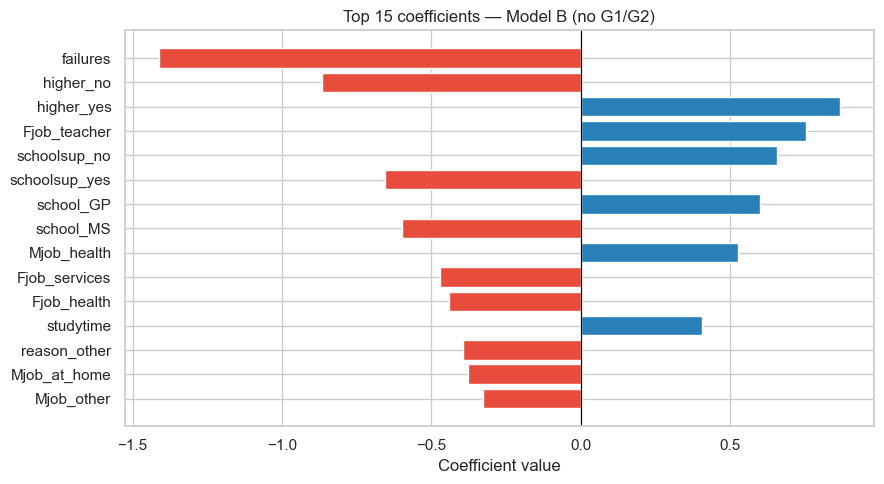

In [14]:
# Fit Model B on the full dataset to inspect coefficients
pipe_b = build_pipeline(habit_features)
pipe_b.fit(df[habit_features], y)

# Retrieve feature names after preprocessing
ohe_cols = (pipe_b.named_steps["preprocessor"]
            .named_transformers_["cat"]
            .named_steps["onehot"]
            .get_feature_names_out(
                df[habit_features].select_dtypes(exclude=[np.number]).columns.tolist()
            ))
num_cols_b = df[habit_features].select_dtypes(include=[np.number]).columns.tolist()
all_feature_names = list(num_cols_b) + list(ohe_cols)

coef_series = pd.Series(
    pipe_b.named_steps["regressor"].coef_,
    index=all_feature_names
).sort_values(key=abs, ascending=False)

print("Top 15 coefficients — Model B (habits only):")
display(coef_series.head(15))

# Plot top 15
top15 = coef_series.head(15)
colors = ["#e74c3c" if v < 0 else "#2980b9" for v in top15.values]
plt.figure(figsize=(9, 5))
plt.barh(top15.index[::-1], top15.values[::-1], color=colors[::-1])
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Top 15 coefficients — Model B (no G1/G2)")
plt.xlabel("Coefficient value")
plt.tight_layout()
plt.show()


### Observations

**Model A vs Model B — performance gap:**
- Model A (with G1, G2): R² ≈ 0.85 — excellent, but largely driven by grade autocorrelation.
- Model B (habits only): R² ≈ 0.30–0.35 — much more modest, which is the honest picture.  
  Study habits, family background, and lifestyle explain roughly **30% of the variance** in G3 once prior grades are removed.

**Most informative features in Model B (from coefficients):**
- `failures` has the largest negative coefficient — consistent with the −0.39 correlation seen earlier.
- `higher_yes` is among the top positive coefficients, confirming the pattern observed in the boxplot.
- `Medu` and `Fedu` (parental education) also appear with positive coefficients.
- `studytime` contributes positively but its coefficient is smaller than the failure and aspiration variables.

**Takeaway:** Prior grades (G1, G2) are overwhelmingly predictive of G3, which limits the practical uplift  
of behavioral variables in a predictive model. However, `failures`, `higher`, and parental education  
remain meaningfully associated with academic outcomes even after removing that signal.


## 7. Limitations and next steps

**Limitations of this analysis:**
- **Single course, single school year**: results may not generalise beyond Portuguese secondary schools.
- **Linear model only**: non-linear relationships (e.g., threshold effects for absences or alcohol) are not captured.
- **No causal inference**: correlations do not imply causation — e.g., students who aspire to higher education may differ in unmeasured ways from those who do not.
- **G3 zeros**: the ~7% of students with G3 = 0 may be a distinct subpopulation (dropouts) rather than low performers, which could distort regression estimates.

**Possible next steps:**
- Separate the math and Portuguese language datasets for a cross-subject comparison.
- Try a model that predicts *dropout* (G3 = 0) as a binary classification task.
- Use SHAP values or permutation importance for a more robust feature importance analysis.
- Explore interaction terms (e.g., `studytime × failures`) or tree-based models (Random Forest, Gradient Boosting).
